<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/AO_003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

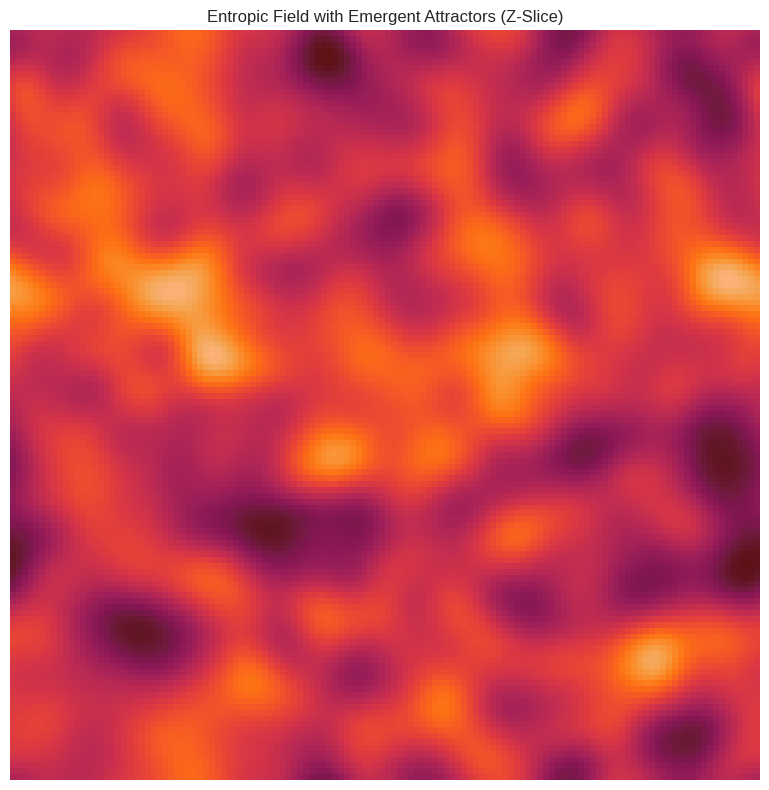

In [1]:
# Matter006: Emergent Attractor Slice from Pure Entropic Dynamics
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Parameters
N = 128          # Lattice size (adjustable)
T = 300          # Time steps
p_seed = 0.02    # Initial attractor seed probability
bond_threshold = 0.01  # Gradient threshold for bonding

# Initialize entropic field and attractors
field = np.random.rand(N, N, N)
attractors = np.random.rand(N, N, N) < p_seed

# Update rule: local entropic smoothing and bonding
def update(field, attractors):
    kernel = np.ones((3, 3, 3)) / 27
    local_avg = convolve(field, kernel, mode='wrap')
    delta = local_avg - field
    field += 0.1 * delta
    grad = np.abs(delta)
    attractors |= (grad < bond_threshold)
    return field, attractors

# Run simulation
for t in range(T):
    field, attractors = update(field, attractors)

# Visualization: central Z-slice
z_slice = N // 2
field_slice = field[:, :, z_slice]
attractor_slice = attractors[:, :, z_slice]

# Plot field and attractors overlay
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(field_slice, cmap='inferno', alpha=0.9)
ax.imshow(attractor_slice, cmap='autumn', alpha=0.3)
ax.set_title("Entropic Field with Emergent Attractors (Z-Slice)")
ax.axis('off')
plt.tight_layout()
plt.show()
